Correcao
janela reduzida para 10s (sinais de 63s tem pouco ruido antes do evento)

Margem reduzida para 3s

Multiplas estações 

Amplitude zero -> investigação


In [2]:
import os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
warnings.filterwarnings('ignore')

PASTA_RAIZ    = r"C:\Users\vish8\OneDrive\Documentos\TCC\data\scedc-pds"
PASTA_XML     = os.path.join(PASTA_RAIZ, "FDSNstationXML")
PASTA_PROJETO = r"C:\Users\vish8\OneDrive\Documentos\TCC\Trabalho\artefacts"
INVENTARIO    = os.path.join(PASTA_PROJETO, "data", "inventario_dados.csv")
PASTA_WINDOWS = os.path.join(PASTA_PROJETO, "data", "windows")
os.makedirs(PASTA_WINDOWS, exist_ok=True)
os.makedirs(os.path.join(PASTA_PROJETO, "figures"), exist_ok=True)

# ── PARÂMETROS (ajustados para sinais curtos de 63s) ─────────────
CANAL_ALVO  = "BHZ"
SR_ALVO     = 40.0 
OUTPUT_RESP = "VEL"
PRE_FILT    = (0.5, 1.0, 18.0, 20.0)
WATER_LEVEL = 60
FREQ_MIN    = 0.5
FREQ_MAX    = 15.0

JANELA_SEG   = 10.0   # ← reduzido de 30s para 10s
SOBREPOSICAO = 0.5
MARGEM_SEG   = 3.0    # ← reduzido de 10s para 3s
N_AMOSTRAS   = int(JANELA_SEG * SR_ALVO)  # 400 amostras

print("✅ Configuração")
print(f"   Janela       : {JANELA_SEG}s = {N_AMOSTRAS} amostras")
print(f"   Sobreposição : {int(SOBREPOSICAO*100)}%")
print(f"   Margem       : {MARGEM_SEG}s antes do evento")
print(f"   Filtro       : {FREQ_MIN}–{FREQ_MAX} Hz")
print()
print("   MUDANÇA PRINCIPAL: usando TODAS as estações BHZ de cada arquivo")
print("   Isso multiplica o volume de dados ~50x")


✅ Configuração
   Janela       : 10.0s = 400 amostras
   Sobreposição : 50%
   Margem       : 3.0s antes do evento
   Filtro       : 0.5–15.0 Hz

   MUDANÇA PRINCIPAL: usando TODAS as estações BHZ de cada arquivo
   Isso multiplica o volume de dados ~50x


In [ ]:
!pip install pandas

  Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl (9.9 MB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
 

In [3]:
import pandas as pd

df_inv = pd.read_csv(INVENTARIO)
df_uso = df_inv[
    (df_inv['xml_disponivel'] == True) &
    (df_inv['razao_var'] > 10)
].copy().reset_index(drop=True)

print(f"Arquivos para processar: {len(df_uso)}")
print(f"Duração média          : {df_uso['duracao_s'].mean():.0f}s")
print(f"t_evento médio         : {df_uso['t_evento_est'].mean():.1f}s")
print()
# Mostrar quantas janelas de ruído esperamos por arquivo com nova config
print("Estimativa de janelas de ruído por arquivo (nova config):")
passo = int(N_AMOSTRAS * (1 - SOBREPOSICAO))
for _, row in df_uso.head(5).iterrows():
    zona_ruido = max(0, row['t_evento_est'] - MARGEM_SEG)
    n_est = max(0, int((zona_ruido * SR_ALVO - N_AMOSTRAS) / passo) + 1)
    print(f"  {row['arquivo']}  t_evento={row['t_evento_est']}s  "
          f"zona_ruido={zona_ruido:.1f}s  ~{n_est} janelas ruído")


Arquivos para processar: 22
Duração média          : 64s
t_evento médio         : 22.3s

Estimativa de janelas de ruído por arquivo (nova config):
  37509232.ms  t_evento=27.0s  zona_ruido=24.0s  ~3 janelas ruído
  37509240.ms  t_evento=11.5s  zona_ruido=8.5s  ~1 janelas ruído
  37509256.ms  t_evento=37.5s  zona_ruido=34.5s  ~5 janelas ruído
  37509264.ms  t_evento=30.0s  zona_ruido=27.0s  ~4 janelas ruído
  37509272.ms  t_evento=25.0s  zona_ruido=22.0s  ~3 janelas ruído


In [ ]:
!pip install obspy

In [4]:
from obspy import read, read_inventory

def encontrar_xml(rede, estacao, pasta_xml):
    for root, _, files in os.walk(pasta_xml):
        for f in files:
            if f.endswith('.xml') and rede in f and estacao in f:
                return os.path.join(root, f)
    return None


def processar_trace(tr_input, caminho_xml):
    """
    Aplica o pipeline em um Trace já carregado (não em arquivo).
    Recebe um objeto obspy.Trace diretamente.
    """
    try:
        tr = tr_input.copy()

        if tr.stats.sampling_rate != SR_ALVO:
            tr.resample(SR_ALVO)

        tr.detrend('linear')
        tr.detrend('demean')
        tr.taper(max_percentage=0.05, type='cosine')

        inv = read_inventory(caminho_xml)
        tr.remove_response(inventory=inv, output=OUTPUT_RESP,
                           pre_filt=PRE_FILT, water_level=WATER_LEVEL)
        tr.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, zerophase=True)

        dados = tr.data.astype(np.float32)

        # Verificar se o sinal é válido (não zerado)
        if dados.std() < 1e-15:
            return None

        return dados
    except Exception:
        return None


def separar_janelas(sinal, sr, t_evento, janela_seg=JANELA_SEG,
                    sobreposicao=SOBREPOSICAO, margem_seg=MARGEM_SEG):
    n_win  = int(janela_seg * sr)
    passo  = int(n_win * (1 - sobreposicao))
    corte_ruido  = int((t_evento - margem_seg) * sr)
    corte_evento = int((t_evento - 2.0) * sr)  # 2s antes do pico

    ruido, evento = [], []
    for inicio in range(0, len(sinal) - n_win + 1, passo):
        fim    = inicio + n_win
        janela = sinal[inicio:fim].copy()
        std    = janela.std()
        if std > 1e-10:
            janela = (janela - janela.mean()) / std
        if   fim   <= corte_ruido  : ruido.append(janela)
        elif inicio >= corte_evento: evento.append(janela)

    r = np.array(ruido,  dtype=np.float32) if ruido  else np.empty((0,n_win), dtype=np.float32)
    e = np.array(evento, dtype=np.float32) if evento else np.empty((0,n_win), dtype=np.float32)
    return r, e


print("✅ Funções definidas")


✅ Funções definidas


In [5]:
all_noise, all_events, metadados, erros = [], [], [], []
total_traces = 0
total_ok     = 0

print(f"Processando {len(df_uso)} arquivos (todas as estações BHZ)...")
print("-" * 72)

for _, row in df_uso.iterrows():
    arquivo = row['arquivo']

    # Carregar o arquivo uma vez
    try:
        st = read(row['caminho'])
    except Exception as e:
        erros.append({'arquivo': arquivo, 'motivo': f'Leitura: {e}'})
        continue

    # Selecionar TODOS os traces BHZ do arquivo
    traces_bhz = [tr for tr in st if tr.stats.channel.endswith(CANAL_ALVO)]

    if not traces_bhz:
        erros.append({'arquivo': arquivo, 'motivo': 'Sem BHZ'})
        continue

    arquivo_ruido  = 0
    arquivo_evento = 0

    for tr in traces_bhz:
        total_traces += 1
        rede    = tr.stats.network
        estacao = tr.stats.station

        # Buscar XML dessa estação
        xml = encontrar_xml(rede, estacao, PASTA_XML)
        if xml is None:
            continue  # sem XML, pula silenciosamente

        # Processar
        dados = processar_trace(tr, xml)
        if dados is None:
            continue

        # Verificar duração
        duracao = len(dados) / SR_ALVO
        if duracao < JANELA_SEG * 2:
            continue

        # Separar janelas usando o t_evento do inventário
        ruido, evento = separar_janelas(dados, SR_ALVO, row['t_evento_est'])

        if len(ruido)  > 0 and ruido.shape[1]  == N_AMOSTRAS:
            all_noise.append(ruido)
            arquivo_ruido += len(ruido)

        if len(evento) > 0 and evento.shape[1] == N_AMOSTRAS:
            all_events.append(evento)
            arquivo_evento += len(evento)

        total_ok += 1

    metadados.append({
        'arquivo'  : arquivo,
        'n_estacoes': len(traces_bhz),
        'razao_var': float(row['razao_var']),
        't_evento' : float(row['t_evento_est']),
        'n_ruido'  : arquivo_ruido,
        'n_evento' : arquivo_evento,
    })

    print(f"  {arquivo:25s}  {len(traces_bhz):3d} BHZ  "
          f"ruído:{arquivo_ruido:4d}  evento:{arquivo_evento:4d}")

# Concatenar
X_noise  = np.concatenate(all_noise,  axis=0) if all_noise  else np.empty((0,N_AMOSTRAS), dtype=np.float32)
X_events = np.concatenate(all_events, axis=0) if all_events else np.empty((0,N_AMOSTRAS), dtype=np.float32)

print()
print("=" * 72)
print(f"Traces BHZ encontrados   : {total_traces}")
print(f"Traces processados OK    : {total_ok}")
print(f"Janelas de ruído         : {len(X_noise):,}")
print(f"Janelas de evento        : {len(X_events):,}")
print(f"Shape ruído              : {X_noise.shape}")
print(f"Shape evento             : {X_events.shape}")


Processando 22 arquivos (todas as estações BHZ)...
------------------------------------------------------------------------
  37509232.ms                127 BHZ  ruído:  33  evento:  77
  37509240.ms                180 BHZ  ruído:   0  evento: 158
  37509256.ms                 51 BHZ  ruído:  15  evento:  12
  37509264.ms                200 BHZ  ruído:  60  evento:  88
  37509272.ms                174 BHZ  ruído:  45  evento: 110
  37509296.ms                 36 BHZ  ruído:   6  evento:   2
  37509320.ms                105 BHZ  ruído:   0  evento: 103
  37509328.ms                 69 BHZ  ruído:  18  evento:  44
  37509336.ms                138 BHZ  ruído:  36  evento:  91
  37509352.ms                 55 BHZ  ruído:   6  evento:  58
  37509368.ms                 99 BHZ  ruído:  35  evento:  38
  37509376.ms                184 BHZ  ruído:   0  evento: 141
  37509384.ms                 27 BHZ  ruído:   2  evento:  17
  37509392.ms                 54 BHZ  ruído:   0  evento:  52
  375094

In [6]:
n  = len(X_noise)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train_noise = X_noise[:n_train]
X_val_noise   = X_noise[n_train : n_train + n_val]
X_test_noise  = X_noise[n_train + n_val:]

n_ev = len(X_events)
n_val_ev = int(n_ev * 0.20)
X_val_events  = X_events[:n_val_ev]
X_test_events = X_events[n_val_ev:]

print("Divisão final:")
print(f"  Ruído  — treino    : {len(X_train_noise):,}")
print(f"  Ruído  — validação : {len(X_val_noise):,}")
print(f"  Ruído  — teste     : {len(X_test_noise):,}")
print(f"  Evento — validação : {len(X_val_events):,}")
print(f"  Evento — teste     : {len(X_test_events):,}")
print()

# Verificação mínima para treinar
if len(X_train_noise) < 50:
    print("⚠️  ATENÇÃO: menos de 50 janelas de ruído para treino.")
    print("   O autoencoder pode não convergir adequadamente.")
    print("   Considere baixar mais dados do SCEDC.")
elif len(X_train_noise) < 200:
    print("⚠️  Volume baixo mas funcional. Resultados podem ser limitados.")
    print("   Recomendado: baixar mais eventos do SCEDC para volume maior.")
else:
    print("✅ Volume suficiente para treino.")


Divisão final:
  Ruído  — treino    : 342
  Ruído  — validação : 73
  Ruído  — teste     : 74
  Evento — validação : 318
  Evento — teste     : 1,272

✅ Volume suficiente para treino.


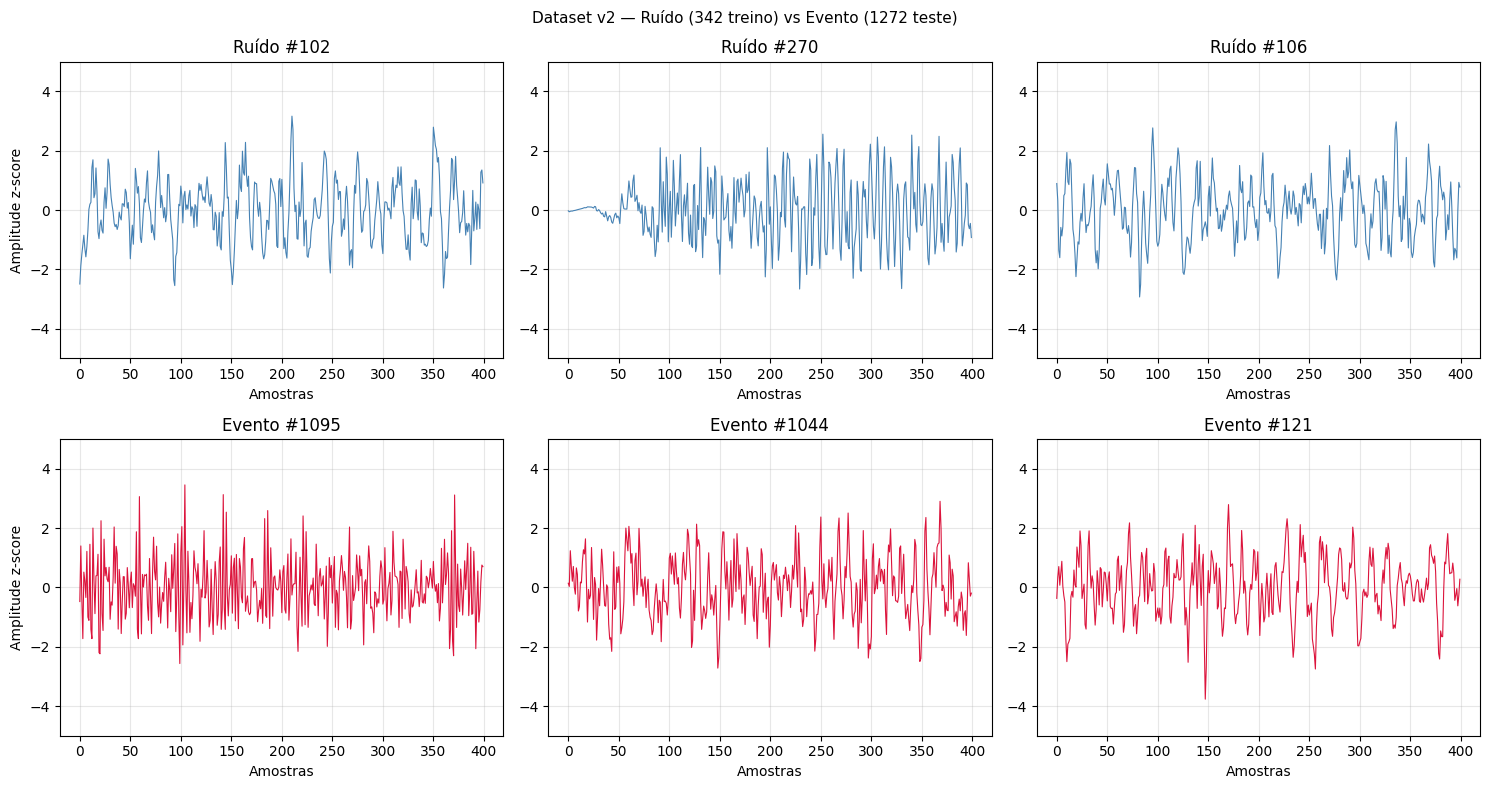

Estatísticas:
                            Ruído      Evento
  Std médio                1.0000      1.0000
  Max abs médio            3.7834      3.3882


In [7]:
if len(X_train_noise) > 0 and len(X_test_events) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    np.random.seed(42)

    for j in range(min(3, len(X_train_noise))):
        idx = np.random.randint(len(X_train_noise))
        axes[0,j].plot(X_train_noise[idx], 'steelblue', lw=0.8)
        axes[0,j].set_title(f'Ruído #{idx}')
        axes[0,j].set_ylim([-5, 5])
        axes[0,j].grid(True, alpha=0.3)
        axes[0,j].set_xlabel('Amostras')
        if j==0: axes[0,j].set_ylabel('Amplitude z-score')

    for j in range(min(3, len(X_test_events))):
        idx = np.random.randint(len(X_test_events))
        axes[1,j].plot(X_test_events[idx], 'crimson', lw=0.8)
        axes[1,j].set_title(f'Evento #{idx}')
        axes[1,j].set_ylim([-5, 5])
        axes[1,j].grid(True, alpha=0.3)
        axes[1,j].set_xlabel('Amostras')
        if j==0: axes[1,j].set_ylabel('Amplitude z-score')

    plt.suptitle(f'Dataset v2 — Ruído ({len(X_train_noise)} treino) vs Evento ({len(X_test_events)} teste)',
                 fontsize=11)
    plt.tight_layout()
    fig_path = os.path.join(PASTA_PROJETO, "figures", "passo2v2_dataset.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

    std_r  = X_train_noise.std(axis=1)
    std_e  = X_test_events.std(axis=1)
    max_r  = np.abs(X_train_noise).max(axis=1)
    max_e  = np.abs(X_test_events).max(axis=1)

    print("Estatísticas:")
    print(f"  {'':20s} {'Ruído':>10s}  {'Evento':>10s}")
    print(f"  {'Std médio':20s} {std_r.mean():>10.4f}  {std_e.mean():>10.4f}")
    print(f"  {'Max abs médio':20s} {max_r.mean():>10.4f}  {max_e.mean():>10.4f}")
else:
    print("⚠️  Volume insuficiente para visualização.")
    print("   É necessário baixar mais dados do SCEDC.")
    print("   Ver célula 7 para instruções.")


In [8]:
noise_path  = os.path.join(PASTA_WINDOWS, "windows_noise_v2.npz")
events_path = os.path.join(PASTA_WINDOWS, "windows_events_v2.npz")

np.savez_compressed(noise_path,
    X_train=X_train_noise, X_val=X_val_noise, X_test=X_test_noise)
np.savez_compressed(events_path,
    X_val=X_val_events, X_test=X_test_events)

info = {
    "versao"      : "2.0",
    "mudancas_v2" : [
        "janela_seg reduzida: 30s -> 10s",
        "margem_seg reduzida: 10s -> 3s",
        "multiplas estacoes por arquivo",
    ],
    "data_geracao": str(np.datetime64('today')),
    "parametros"  : {
        "canal"        : CANAL_ALVO,
        "sr_hz"        : SR_ALVO,
        "janela_seg"   : JANELA_SEG,
        "n_amostras"   : N_AMOSTRAS,
        "sobreposicao" : SOBREPOSICAO,
        "margem_seg"   : MARGEM_SEG,
        "freq_min"     : FREQ_MIN,
        "freq_max"     : FREQ_MAX,
    },
    "dataset"     : {
        "n_arquivos"   : len(df_uso),
        "n_train"      : int(len(X_train_noise)),
        "n_val_noise"  : int(len(X_val_noise)),
        "n_test_noise" : int(len(X_test_noise)),
        "n_val_events" : int(len(X_val_events)),
        "n_test_events": int(len(X_test_events)),
    },
    "por_arquivo" : metadados
}

info_path = os.path.join(PASTA_WINDOWS, "dataset_info_v2.json")
with open(info_path, 'w', encoding='utf-8') as f:
    json.dump(info, f, indent=2, ensure_ascii=False)

check = np.load(noise_path)
print("✅ Dataset v2 salvo")
print()
for p in [noise_path, events_path, info_path]:
    print(f"  {os.path.basename(p):35s}  {os.path.getsize(p)/1024:8.1f} KB")
print()
print(f"  X_train : {check['X_train'].shape}")
print(f"  X_val   : {check['X_val'].shape}")
print(f"  X_test  : {check['X_test'].shape}")
print()
print("=" * 60)
print("🚀 PASSO 2 v2 CONCLUÍDO")
if len(X_train_noise) >= 200:
    print("   Volume suficiente → Passo 3: STA/LTA")
else:
    print("   ⚠️  Volume baixo → execute Célula 7 para baixar mais dados")


✅ Dataset v2 salvo

  windows_noise_v2.npz                    711.2 KB
  windows_events_v2.npz                  2303.4 KB
  dataset_info_v2.json                      4.2 KB

  X_train : (342, 400)
  X_val   : (73, 400)
  X_test  : (74, 400)

🚀 PASSO 2 v2 CONCLUÍDO
   Volume suficiente → Passo 3: STA/LTA
